
<h3 align="center">SA4110 MACHINE LEARNING APPLICATION DEVELOPMENT</h3>
<h4 align="center">CA - GROUP 3 - IMAGE CLASSIFIER</h4>
<hr>

<div class="alert alert-block alert-info">
<b><u>Tasks:</u></b> 
<ol>
<li>Create an Image Classifier (CNN model) to classify images of fruits correctly.</li>
<li>A Fruits Dataset is provided that consists of these 3 Classes: -</li>
    <ul>
    <li>Apple</li>
    <li>Banana</li>
    <li>Orange</li>
    </ul>
<li>Use the Images in train.zip and test.zip to Train and Test your Image Classifier.</li>
<li>Document your experiments and results in improving your model’s accuracy.</li>
<li>The Following Activities can Improve your Model’s Accuracy: -</li>
    <ul>
    <li>Balance out the Number of Samples in Each Class</li>
    <li>Correct any mis-labelling in any of the 3 Classes</li>
    <li>Image Augmentation to Generate more Data </li>
    </ul>
<li>Use Matplotlib to Generate any Plots that can Help the Reader understand your Work Better.</li>
</ol></div>



## Set Up & Preprocessing
1. Installations
2. Imports
3. Image preprocessing

In [2]:
# ========================================================== #
# 1. (Optional) Verification of Base Libraries / Packages 
# Purpose: Verify that the host environment has the necessary
# packages or libraries required to run the script.
# ========================================================== #

import sys
import subprocess
import importlib.util

def verify_and_install():
    required_packages = {
        'pandas': 'pandas',
        'numpy': 'numpy',
        'matplotlib': 'matplotlib',
        'seaborn': 'seaborn',
        'IPython': 'ipython',
        'PIL': 'Pillow',
        'torch': 'torch',
        'torchvision': 'torchvision',
        'keras': 'keras',
        'sklearn': 'scikit-learn'
    }

    print("--- Verifying Environment Setup ---")
    
    for import_name, pip_name in required_packages.items():
        # Check if the module can be found in the host environment
        if importlib.util.find_spec(import_name) is None:
            print(f"❌ '{import_name}' is missing. Installing '{pip_name}'...")
            try:
                # Run pip install securely via the current python executable
                subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name])
                print(f"✅ Successfully installed '{pip_name}'.")
            except subprocess.CalledProcessError as e:
                # Stop the script if a critical package fails to install
                print(f"⚠️ Failed to install '{pip_name}'. Error: {e}")
                sys.exit(1) 
        else:
            print(f"✅ '{import_name}' is already installed.")
            
    print("-" * 70)
    print("All necessary packages are ready. Proceeding with the script...")
    print("-" * 70 + "\n")

# Run the verification before importing the third-party libraries
verify_and_install()

--- Verifying Environment Setup ---
✅ 'pandas' is already installed.
✅ 'numpy' is already installed.
✅ 'matplotlib' is already installed.
✅ 'seaborn' is already installed.
✅ 'IPython' is already installed.
✅ 'PIL' is already installed.
✅ 'torch' is already installed.
✅ 'torchvision' is already installed.
✅ 'keras' is already installed.
✅ 'sklearn' is already installed.
----------------------------------------------------------------------
All necessary packages are ready. Proceeding with the script...
----------------------------------------------------------------------



In [3]:
# ========================================================== #
# 2. Importing the Required Libraries and Packages
# Purpose: Import the Libraries and Packages to the Host
# Environment for Data Manipulation, Visualization, Image Processing,
# Deep Learning, and Machine Learning Utilities.
# ========================================================== #

# A. System and OS-level operations
import os
import statistics
from pathlib import Path
os.environ["KERAS_BACKEND"] = "torch"

# B. Data Manipulation and Mathematical Operations
import pandas as pd
import numpy as np

# C. Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

# D. Image Processing
from PIL import Image

# E. Deep Learning Frameworks (PyTorch & Keras)
import torch
import keras
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

# F. Machine Learning Utilities and Metrics (Scikit-Learn)
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report


In [92]:
# Helper fns to render HTML components
def render_df(df, sample_size):

    # Dynamic sampling based on input size
    display_df = (
        df if sample_size == 0
        else df.sample(n=min(sample_size, len(df)))
    )
    
    return (display_df.style
        .set_properties(**{'text-align': 'center', 'color': 'black'})
        .set_table_styles([
            {'selector':'tr:nth-child(even)', 'props': [('background-color', 'azure')]},
            {'selector':'th', 'props':[('text-align', 'center'), ('color', 'black'), ('font-weight', 'bold')]},
            {'selector':'tr:nth-child(odd)', 'props':[('text-align', 'center'), ('background-color', 'paleturquoise')]}
        ])).to_html()

def render_section_header(title):
    return f"""
    <h4 style='text-align: left; margin-top: 15px; margin-bottom: 5px;'>
        {title}
    </h4>
    """

def render_key_value_table(rows):
    """
    rows = [
        ("Label 1", "Value 1"),
        ("Label 2", "Value 2"),
    ]
    """

    html = "<table style='margin: 0; text-align: left; border: none;'>"

    for i, (label, value) in enumerate(rows):
        bg = "paleturquoise" if i % 2 == 0 else "azure"

        html += f"""
        <tr style='background-color: {bg};'>
            <td style='color: black;
                       text-align: center;
                       padding-right: 10px;
                       border: none;'>
                <strong>{label}</strong>
            </td>
            <td style='color: black;
                       text-align: center;
                       border: none;'>
                {value}
            </td>
        </tr>
        """

    html += "</table>"
    return html


def render_status_list(messages):
    """
    messages = [
        ("green", "Success"),
        ("red", "Failure")
    ]
    """

    html = "<ul style='text-align: left;'>"

    for color, msg in messages:
        html += f"<li style='color: {color};'>{msg}</li>"

    html += "</ul>"
    return html


def render_separator():
    return "<hr style='margin-top: 15px; border-top: 1px solid #ddd;'>"

In [93]:
# ========================================================== #
# 3. Load and Process the Image Data from the Directories
# Purpose: Scan the 'train' and 'test' directories for .jpg 
# images, extract class labels from filenames, calculate 
# median dimensions, and compile the data into DataFrames 
# for prior for model training and evaluation.
# ========================================================== #

def process_image_directory(directory_path, dataset_name="Dataset"):
    
    file_names = []
    class_labels = []
    widths = []
    heights = []
    status_messages = []

    # Single pass through the directory
    for img_path in directory_path.glob("*.jpg"):
        try:
            # A. Open a valid data image file and extract its dimensions
            with Image.open(img_path) as img:
                widths.append(img.size[0])
                heights.append(img.size[1])
                
            # B. Extract metadata ONLY if the image opened successfully
            file_names.append(img_path.name)
            class_labels.append(img_path.name.strip().split('_')[0])
            
        except Exception as e:
            # C. Exception handling for invalid data image file
            status_messages.append(("red", f"Error reading {img_path.name}: {e}"))

    # Success message if no errors
    if not status_messages:
        status_messages.append(("green", "All images read successfully without errors."))

    # Build the DataFrame Table of Consisting of File Name and its Classes
    df = pd.DataFrame({
        'fileName': file_names,
        'classLabel': class_labels
    })

    # Build HTML Report

    log_html = ""

    log_html += render_section_header("Processing Status")
    log_html += render_status_list(status_messages)

    log_html += render_section_header("Class Labels Found")
    log_html += render_key_value_table([
        (f"Class {i}", label)
        for i, label in enumerate(df['classLabel'].unique(), start = 1)
    ])

    # Calculate Medians of the data images 
    median_w, median_h = 0, 0
    log_html += render_section_header("<br>Dataset Statistics")
    
    if widths and heights:
        median_w = statistics.median(widths)
        median_h = statistics.median(heights)
        
        log_html += render_key_value_table([
            ("Total Images Evaluated", len(widths)),
            ("Image Median Width", f"{median_w} px"),
            ("Image Median Height", f"{median_h} px")
        ])
    else:
        log_html += "<div style='color: red; text-align: center;'>No valid .jpg images found.</div>"
        
    log_html += render_separator()
        
    return df, median_w, median_h, log_html

In [99]:
# ---------------------------------------------------------- #
# Execute the Function for Both Directories
# ---------------------------------------------------------- #

# Define the path directories
base_dir = Path.cwd().parents[0]
img_train_dir = base_dir / "train"
img_test_dir = base_dir / "test"

# Process Training and Validation Datasets from 'train' directory
class_train_df, img_T_widths_median, img_T_heights_median, train_logs = process_image_directory(
    directory_path = img_train_dir, 
    dataset_name = "Training and Validation Dataset"
)

# Sampling of the training and validation dataframe for verification
train_html = render_html(class_train_df, 5)

# Process Testing Datasets from 'test' directory
class_test_df, img_t_widths_median, img_t_heights_median, test_logs = process_image_directory(
    directory_path = img_test_dir, 
    dataset_name = "Testing Dataset"
)

# Sampling of the testing dataframe for verification
test_html = render_html(class_test_df, 5)

# Wrapping them html in a Flex container to enable side-by-side display
train_test_html = f"""
<div style="display: flex; flex-direction: row; justify-content: space-around; align-items: flex-start; gap: 20px;">
    <div style="flex: 1; padding: 10px; border: 1px solid #ccc; border-radius: 16px;">
        <h3 style="text-align: center; color: 'black';">Training & Validation Dataset</h3>
        <div style="display: flex; flex-direction: column; justify-content: center;">
            {train_logs}
        </div>
        <h4 style="text-align: center;">DataFrame Sample</h4>
        <div style="display: flex; flex-direction: column; justify-content: center;">
            {train_html}
        </div>
    </div>
    
    <div style="flex: 1; padding: 10px; border: 1px solid #ccc; border-radius: 16px;">
        <h3 style="text-align: center; color: 'black';">Testing Dataset</h3>
        <div style="display: flex; flex-direction: column; justify-content: center;">
            {test_logs}
        </div>
        <h4 style="text-align: center;">DataFrame Sample</h4>
        <div style="display: flex; flex-direction: column; justify-content: center;">
            {test_html}
        </div>
    </div>
</div>
"""
display(HTML(train_test_html))

In [100]:
# ========================================================== #
# 4. Define a New Class: FruitLabeller and Supporting Functions
# Purpose: Create a custom PyTorch Dataset to load images, apply 
# transformations, and encode string labels to numeric indices 
# using a provided DataFrame. Includes a helper function to 
# visually summarize the dataset's class distribution.
# ========================================================== #

class FruitLabeller(Dataset):
    def __init__(self, class_dataframe, img_directory, transforms = None):
        self.dataframe = class_dataframe
        self.directory = img_directory
        self.transforms = transforms

        unique_labels = sorted(class_dataframe['classLabel'].unique())
        self.label_map = {label: idx for idx, label in enumerate(unique_labels)}
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        img_name = self.dataframe.iloc[idx]['fileName']
        img_path = self.directory / img_name
        image = Image.open(img_path).convert("RGB")

        label_str = self.dataframe.iloc[idx]['classLabel']
        label = self.label_map[label_str]

        if self.transforms:
            image = self.transforms(image)
        
        return image, label
    
def render_dataset_shape(df):
    shape_df = df['classLabel'].value_counts().sort_index().reset_index()
    shape_df.columns = ['Class Label', 'Total Image']
    return shape_df

## Model Build and Training
1. Data preparation
2. CNN architecture
3. Combile model
4. Train model

In [103]:
# Data preparation

# Set Target Size (Max 224x224)
target_width = int(img_T_widths_median) if img_T_widths_median < 224 else 224
target_height = int(img_T_heights_median) if img_T_heights_median < 224 else 224

# Split Data (80% Train, 20% Val)
train_df, val_df = train_test_split(
    class_train_df,
    test_size=0.2,
    random_state=42,
    stratify=class_train_df['classLabel']
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

# Define PyTorch Transformations
train_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop((target_height, target_width)),
    transforms.ToTensor()
])

test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop((target_height, target_width)),
    transforms.ToTensor()
])

# Instantiate PyTorch Datasets
train_dataset = FruitLabeller(train_df, img_train_dir, train_transforms)
val_dataset = FruitLabeller(val_df, img_train_dir, test_transforms)
test_dataset = FruitLabeller(class_test_df, img_test_dir, test_transforms)

# Create PyTorch DataLoaders
train_loader = DataLoader(train_dataset, batch_size=9, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=9, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=9, shuffle=False)

# Display Dataset Shapes
# display_dataset_shape(train_df, "Training (80%)")
# display_dataset_shape(val_df, "Validation (20%)")
# display_dataset_shape(class_test_df, "Testing")
train_shape_html = render_html(render_dataset_shape(train_df), 0)
val_shape_html = render_html(render_dataset_shape(val_df), 0)
class_test_shape_html = render_html(render_dataset_shape(class_test_df), 0)

# Wrapping them html in a Flex container to enable side-by-side display
data_shapes_html = f"""
<div style="display: flex; flex-direction: row; justify-content: space-around; align-items: flex-start; gap: 20px;">
    <div style="flex: 1; padding: 10px; border: 1px solid #ccc; border-radius: 16px;">
        <h3 style="text-align: center; color: 'black';">Training (80%)<br>Dataset Shape:</h3>
        <div style="display: flex; flex-direction: column; justify-content: center;">
            {train_shape_html}
        </div>
    </div>
    
    <div style="flex: 1; padding: 10px; border: 1px solid #ccc; border-radius: 16px;">
        <h3 style="text-align: center; color: 'black';">Validation (20%)<br>Dataset Shape:</h3>
        <div style="display: flex; flex-direction: column; justify-content: center;">
            {val_shape_html}
        </div>
    </div>

    <div style="flex: 1; padding: 10px; border: 1px solid #ccc; border-radius: 16px;">
        <h3 style="text-align: center; color: 'black';">Testing<br>Dataset Shape:</h3>
        <div style="display: flex; flex-direction: column; justify-content: center;">
            {class_test_shape_html}
        </div>
    </div>
</div>
"""

display(HTML(data_shapes_html))

,Class Label,Total Image
0,apple,60
1,banana,58
2,orange,58
,Class Label,Total Image
0,apple,15
1,banana,15
2,orange,14
,Class Label,Total Image
0,apple,19
1,banana,18


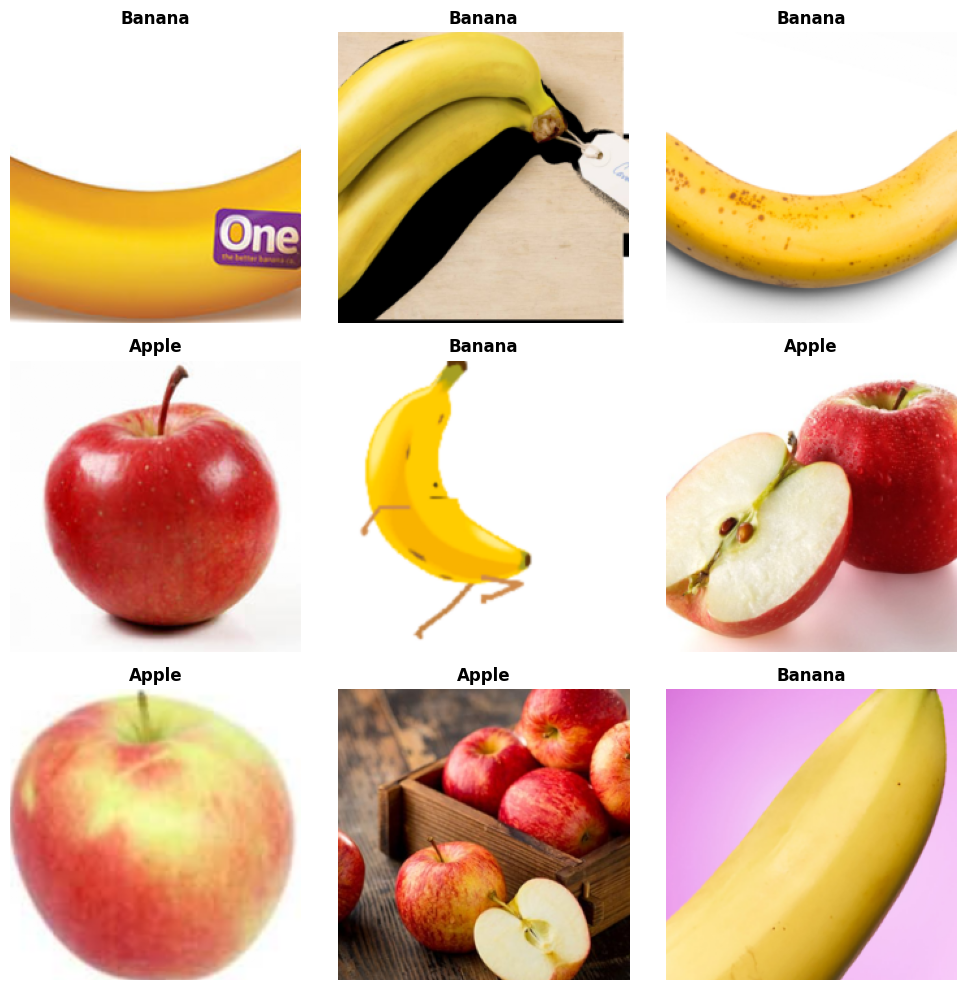

In [104]:
# Display Sample Images
images, labels = next(iter(train_loader))
class_names = {v: k for k, v in train_dataset.label_map.items()}

# Set up a 5 x 5 MatPlotLib Grid
fig, axes = plt.subplots(3, 3, figsize=(10, 10))

for i, ax in enumerate(axes.flat):
    img = np.transpose(images[i].numpy(), (1, 2, 0))
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    
    # Look up the Integer Label in the Dictionary and Set it as the Title
    label_idx = labels[i].item()
    ax.set_title(class_names[label_idx].capitalize(), fontsize=12, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# CNN Architecture (224 x 224 x 3)

model = keras.Sequential([
    keras.layers.Input(shape=(3, 224, 224)),

    # Conv1: 32 filters, Output shape: 224 x 224 x 32
    # PURPOSE: This is the first layer that interacts with the raw image. It scans the 
    # image using a sliding window (kernel) to detect basic, low-level spatial features 
    # like edges, simple textures, and color gradients.
    keras.layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        padding="same",
        activation="relu",
        data_format="channels_first" # PyTorch default
    ),

    # MaxPool: 224 x 224 -> 112 x 112
    # PURPOSE: Downsamples the feature maps produced by the convolutional layer. 
    # It takes the maximum value from a 2 x 2 window, effectively reducing the width and 
    # height of the image data by half. This reduces computational cost, controls overfitting, 
    # and makes the network robust to small shifts or translations in the image.
    keras.layers.MaxPooling2D(pool_size=(2, 2), data_format="channels_first"),

    # Conv2: 64 filters, output shape: 112 x 112 x 64
    # PURPOSE: Takes the pooled feature maps from the previous layer and scans them again.
    # Because it's looking at downsampled data, it can learn higher-level, more complex 
    # and abstract features (like shapes or parts of fruits). We increase the 
    # number of filters (to 64) to capture more complex representations.
    keras.layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        padding="same",
        activation="relu",
        data_format="channels_first"
    ),

    # MaxPool: 112 x 112 -> 56 x 56
    # PURPOSE: Downsamples the feature maps produced by the convolutional layer. 
    # It takes the maximum value from a 2 x 2 window, effectively reducing the width and 
    # height of the image data by half. This reduces computational cost, controls overfitting, 
    # and makes the network robust to small shifts or translations in the image.
    keras.layers.MaxPooling2D(pool_size=(2, 2), data_format="channels_first"),
    
    
    # Conv3: 128 filters, output shape: 56 x 56 x 128
    # PURPOSE: Takes the pooled feature maps from the previous layer and scans them again.
    # Because it's looking at downsampled data, it can learn higher-level, more complex 
    # and abstract features (like shapes or parts of fruits). We increase the 
    # number of filters (to 128) to capture more complex representations.
    keras.layers.Conv2D(
        filters=128,
        kernel_size=(3, 3),
        padding="same",
        activation="relu",
        data_format="channels_first"
    ),

    # MaxPool: 56 x 56 -> 28 x 28
    # PURPOSE: Downsamples the feature maps produced by the convolutional layer. 
    # It takes the maximum value from a 2 x 2 window, effectively reducing the width and 
    # height of the image data by half. This reduces computational cost, controls overfitting, 
    # and makes the network robust to small shifts or translations in the image.
    keras.layers.MaxPooling2D(pool_size=(2, 2), data_format="channels_first"),
    
    # Flatten: 28 x 28 x 128 = 100,352
    # PURPOSE: Convolutional layers output 3D tensors (height, width, channels). However, 
    # our final classification layers (Dense layers) require 1D arrays. This layer simply 
    # unrolls the 3D data into a flat 1D vector.
    keras.layers.Flatten(),

    # Fully connected layer
    # PURPOSE: Acts as the "brain" of the network. It looks at all the flattened features 
    # extracted by the convolutional layers and learns which combinations of features 
    # correlate with which specific fruit classes.
    keras.layers.Dense(128, activation="relu"),

    # Dropout 
    # PURPOSE: Disables 50% of neurons to prevent memorizing the training data
    # keras.layers.Dropout(0.5), 
    
    # Output Layer: 3 nodes (Apples, Bananas, Oranges)
    # PURPOSE: Produces the final prediction. 
    # - activation ('softmax'): Converts the raw output scores into a probability 
    # distribution, where all outputs sum up to 1. The highest probability is the prediction.
    keras.layers.Dense(3, activation='softmax')
])

# Display the network structure and parameter count
model.summary()